In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df_obs_cohort_lee = pd.read_csv('../../data/lee_obs_cohort.csv')
df_pred_cohort_lee = pd.read_csv('../../data/lee_forecasts_cohort.csv')
df_obs_cohort_dl = pd.read_csv('../../data/dl_obs_cohort_fewer_ages_refit.csv')
df_pred_cohort_dl = pd.read_csv('../../data/dl_forecasts_cohort_fewer_ages_refit.csv')
df_pred_cohort_fr = pd.read_csv('../../data/freeze_forecasts_cohort.csv')
df_obs_cohort_fr = pd.read_csv('../../data/freeze_obs_cohort.csv')
df_pred_cohort_my = pd.read_csv('../../data/myrskyla_forecasts_cohort.csv')
df_obs_cohort_my = pd.read_csv('../../data/myrskyla_obs_cohort.csv')
df_pred_cohort_db = pd.read_csv('../../data/debeer_forecasts_cohort.csv')
df_obs_cohort_db = pd.read_csv('../../data/debeer_obs_cohort.csv')

In [6]:
# Filter forecasts to only periods after the jump-off year (drop reproduced observed rates)
# Year is the birth cohort; the period of each observation is Year + Age
df_pred_cohort_lee = df_pred_cohort_lee[df_pred_cohort_lee['Year'] + df_pred_cohort_lee['Age'] > df_pred_cohort_lee['JumpOffYear']]
df_pred_cohort_dl = df_pred_cohort_dl[df_pred_cohort_dl['Year'] + df_pred_cohort_dl['Age'] > df_pred_cohort_dl['JumpOffYear']]
df_pred_cohort_fr = df_pred_cohort_fr[df_pred_cohort_fr['Year'] + df_pred_cohort_fr['Age'] > df_pred_cohort_fr['JumpOffYear']]
df_pred_cohort_my = df_pred_cohort_my[df_pred_cohort_my['Year'] + df_pred_cohort_my['Age'] > df_pred_cohort_my['JumpOffYear']]
df_pred_cohort_db = df_pred_cohort_db[df_pred_cohort_db['Year'] + df_pred_cohort_db['Age'] > df_pred_cohort_db['JumpOffYear']]

In [12]:
# Retain only rows shared across all models' forecasts (match on identifiers, not Rate)
key_cols = ['Country', 'Year', 'Age', 'JumpOffYear']
pred_dfs = [df_pred_cohort_lee, df_pred_cohort_dl, df_pred_cohort_fr, df_pred_cohort_my, df_pred_cohort_db]

common_keys = pred_dfs[0][key_cols].drop_duplicates()
for df in pred_dfs[1:]:
    common_keys = common_keys.merge(df[key_cols].drop_duplicates(), on=key_cols, how='inner')

df_pred_cohort_lee = df_pred_cohort_lee.merge(common_keys, on=key_cols, how='inner')
df_pred_cohort_dl = df_pred_cohort_dl.merge(common_keys, on=key_cols, how='inner')
df_pred_cohort_fr = df_pred_cohort_fr.merge(common_keys, on=key_cols, how='inner')
df_pred_cohort_my = df_pred_cohort_my.merge(common_keys, on=key_cols, how='inner')
df_pred_cohort_db = df_pred_cohort_db.merge(common_keys, on=key_cols, how='inner')

In [13]:
# RMSE table: observed vs predicted rates for each forecast method
def rmse(pred_df, obs_df, method):
    merged = pred_df.merge(
        obs_df[key_cols + ['Rate']], on=key_cols, how='inner',
        suffixes=('_pred', '_obs')
    )
    err = np.sqrt(np.mean((merged['Rate_pred'] - merged['Rate_obs']) ** 2))
    return {'Method': method, 'RMSE': err, 'N': len(merged)}

rmse_table = pd.DataFrame([
    rmse(df_pred_cohort_lee, df_obs_cohort_lee, 'LeeCarter'),
    rmse(df_pred_cohort_dl, df_obs_cohort_dl, 'DL'),
    rmse(df_pred_cohort_fr, df_obs_cohort_fr, 'FreezeRates'),
    rmse(df_pred_cohort_my, df_obs_cohort_my, 'Myrskyla2013'),
    rmse(df_pred_cohort_db, df_obs_cohort_db, 'deBeer'),
]).sort_values('RMSE').reset_index(drop=True)

rmse_table

,Method,RMSE,N
0,DL,0.018928,118650
1,Myrskyla2013,0.021358,118650
2,FreezeRates,0.023329,118650
3,deBeer,0.024341,118650
4,LeeCarter,0.026991,118650


In [ ]:
# RMSE by jump-off year for each forecast method
def rmse_by_joy(pred_df, obs_df, method):
    merged = pred_df.merge(
        obs_df[key_cols + ['Rate']], on=key_cols, how='inner',
        suffixes=('_pred', '_obs')
    )
    g = merged.groupby('JumpOffYear').apply(
        lambda d: np.sqrt(np.mean((d['Rate_pred'] - d['Rate_obs']) ** 2))
    )
    g.name = method
    return g

rmse_joy_table = pd.concat([
    rmse_by_joy(df_pred_cohort_lee, df_obs_cohort_lee, 'LeeCarter'),
    rmse_by_joy(df_pred_cohort_dl, df_obs_cohort_dl, 'Deep Learning'),
    rmse_by_joy(df_pred_cohort_fr, df_obs_cohort_fr, 'Freeze Rates'),
    rmse_by_joy(df_pred_cohort_my, df_obs_cohort_my, 'Myrskyla'),
    rmse_by_joy(df_pred_cohort_db, df_obs_cohort_db, 'deBeer'),
], axis=1)

rmse_joy_table

,LeeCarter,DL,FreezeRates,Myrskyla2013,deBeer
JumpOffYear,,,,,
1985,0.032799,0.024998,0.030810,0.026866,0.031254
1990,0.037237,0.021897,0.030369,0.029249,0.030683
1995,0.025233,0.018196,0.021691,0.019645,0.024223
2000,0.020548,0.016435,0.016883,0.014165,0.019094
2005,0.013369,0.012635,0.012700,0.011096,0.013968
2010,0.012463,0.009611,0.010775,0.012454,0.009833


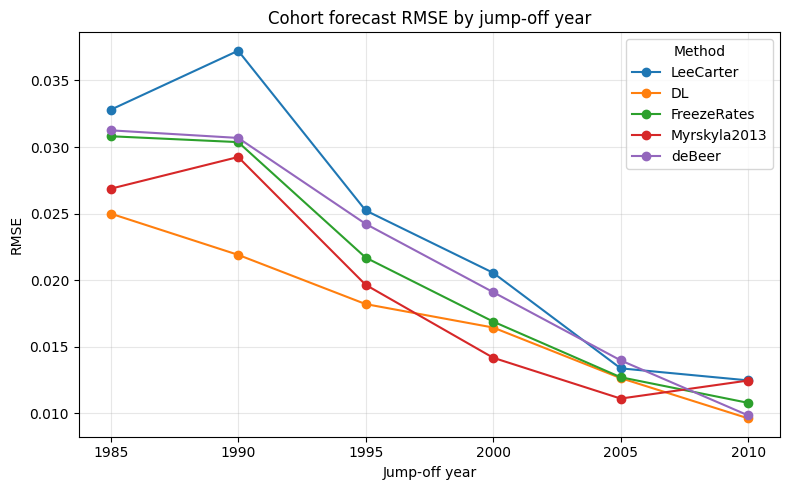

In [15]:
# Plot RMSE by jump-off year for each method
fig, ax = plt.subplots(figsize=(8, 5))
for method in rmse_joy_table.columns:
    ax.plot(rmse_joy_table.index, rmse_joy_table[method], marker='o', label=method)

ax.set_xlabel('Jump-off year')
ax.set_ylabel('RMSE')
ax.set_title('Cohort forecast RMSE by jump-off year')
ax.legend(title='Method')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

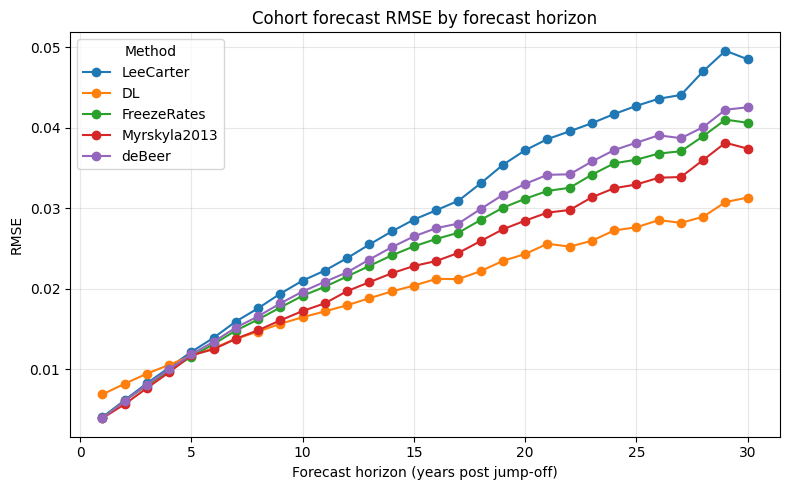

In [16]:
# RMSE by forecast horizon (years post jump-off) for each method
# Horizon = period (Year + Age) - JumpOffYear
def rmse_by_horizon(pred_df, obs_df, method):
    merged = pred_df.merge(
        obs_df[key_cols + ['Rate']], on=key_cols, how='inner',
        suffixes=('_pred', '_obs')
    )
    merged['Horizon'] = merged['Year'] + merged['Age'] - merged['JumpOffYear']
    g = merged.groupby('Horizon').apply(
        lambda d: np.sqrt(np.mean((d['Rate_pred'] - d['Rate_obs']) ** 2))
    )
    g.name = method
    return g

rmse_horizon_table = pd.concat([
    rmse_by_horizon(df_pred_cohort_lee, df_obs_cohort_lee, 'LeeCarter'),
    rmse_by_horizon(df_pred_cohort_dl, df_obs_cohort_dl, 'DL'),
    rmse_by_horizon(df_pred_cohort_fr, df_obs_cohort_fr, 'FreezeRates'),
    rmse_by_horizon(df_pred_cohort_my, df_obs_cohort_my, 'Myrskyla2013'),
    rmse_by_horizon(df_pred_cohort_db, df_obs_cohort_db, 'deBeer'),
], axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
for method in rmse_horizon_table.columns:
    ax.plot(rmse_horizon_table.index, rmse_horizon_table[method], marker='o', label=method)

ax.set_xlabel('Forecast horizon (years post jump-off)')
ax.set_ylabel('RMSE')
ax.set_title('Cohort forecast RMSE by forecast horizon')
ax.legend(title='Method')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

{0: np.str_('AUT'), 1: np.str_('BEL'), 2: np.str_('BGR'), 3: np.str_('BLR'), 4: np.str_('CAN'), 5: np.str_('CHE'), 6: np.str_('CHL'), 7: np.str_('CZE'), 8: np.str_('DEUTE'), 9: np.str_('DEUTNP'), 10: np.str_('DEUTW'), 11: np.str_('DNK'), 12: np.str_('ESP'), 13: np.str_('EST'), 14: np.str_('FIN'), 15: np.str_('FRATNP'), 16: np.str_('GBR_NIR'), 17: np.str_('GBR_NP'), 18: np.str_('GBR_SCO'), 19: np.str_('GBRTENW'), 20: np.str_('HRV'), 21: np.str_('HUN'), 22: np.str_('IRL'), 23: np.str_('ISL'), 24: np.str_('ITA'), 25: np.str_('JPN'), 26: np.str_('KOR'), 27: np.str_('LTU'), 28: np.str_('NLD'), 29: np.str_('NOR'), 30: np.str_('POL'), 31: np.str_('PRT'), 32: np.str_('RUS'), 33: np.str_('SVK'), 34: np.str_('SVN'), 35: np.str_('SWE'), 36: np.str_('TWN'), 37: np.str_('UKR'), 38: np.str_('USA')}


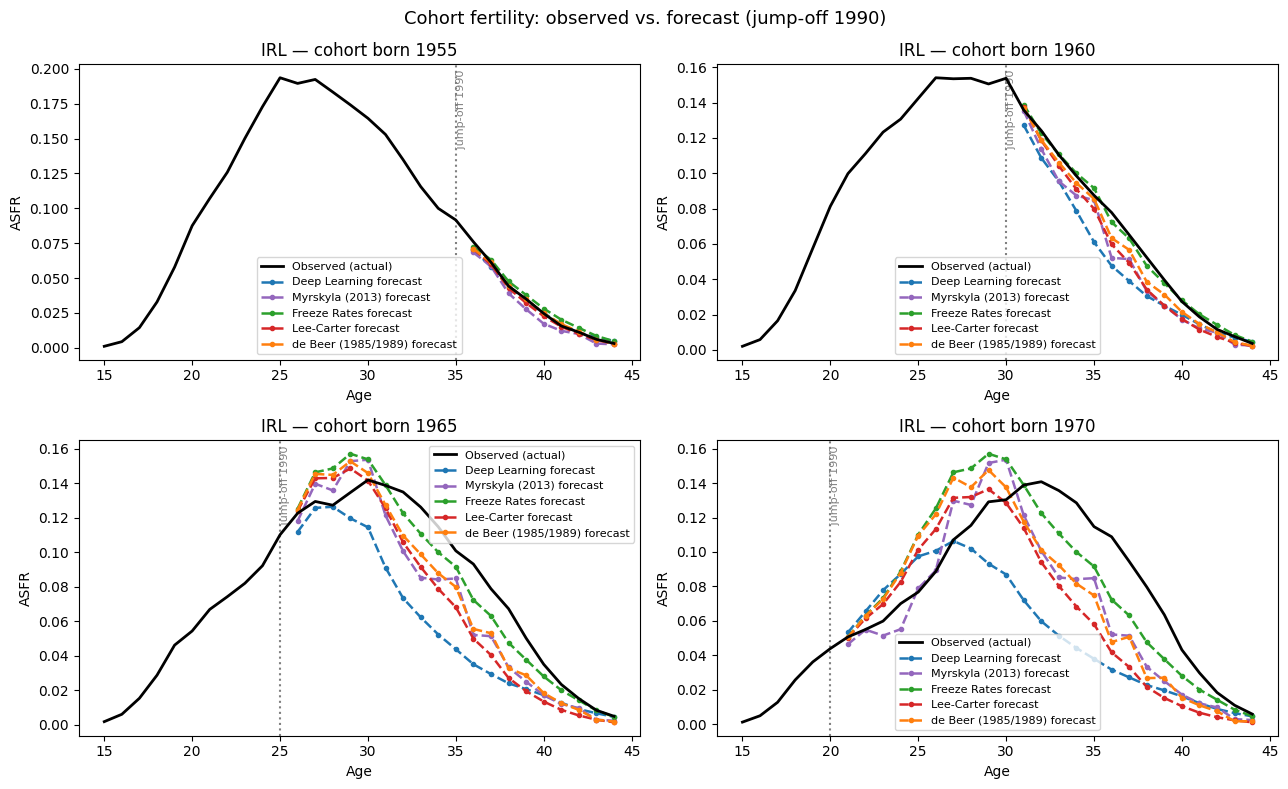

In [18]:
# ============================================================
# Observed vs. forecast cohort fertility trajectories
# ============================================================

# country index -> country code (for nicer titles)
_geos = np.load('../../data/geos_key.npy', allow_pickle=True)
GEO_NAMES = {int(idx): code for code, idx in _geos}
print(GEO_NAMES)

# Each method: label -> (observed_df, predicted_df, color)
METHODS = {
    'Deep Learning':   (df_obs_cohort_dl,  df_pred_cohort_dl,  '#1f77b4'),
    'Lee-Carter':      (df_obs_cohort_lee, df_pred_cohort_lee, '#d62728'),
    'Freeze Rates':    (df_obs_cohort_fr,  df_pred_cohort_fr,  '#2ca02c'),
    'Myrskyla (2013)': (df_obs_cohort_my,  df_pred_cohort_my,  '#9467bd'),
    'de Beer (1985/1989)': (df_obs_cohort_db,  df_pred_cohort_db,  '#ff7f0e'),
}


def plot_cohort_forecasts(country, jump_off_year, birth_years,
                          methods=('Deep Learning',)):
    """Trace observed vs. forecast ASFR over age for a selection of cohorts.

    One subplot per cohort (identified by birth `Year`). Observed rates are
    drawn as a solid black line across all ages; each method's forecast is a
    dashed colored line for the post-jump-off ages. A dotted vertical line
    marks the jump-off year, which for a cohort born in `by` sits at
    age = jump_off_year - by.
    """
    n = len(birth_years)
    ncols = min(2, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4 * nrows),
                             squeeze=False)
    axes = axes.ravel()

    for ax, by in zip(axes, birth_years):
        split_age = jump_off_year - by  # age at which the jump-off year falls

        # --- observed truth (same across methods) ---
        obs_df = METHODS[methods[0]][0]
        obs = obs_df[(obs_df['Country'] == country) &
                     (obs_df['JumpOffYear'] == jump_off_year) &
                     (obs_df['Year'] == by)].sort_values('Age')
        if not obs.empty:
            ax.plot(obs['Age'], obs['Rate'], '-', color='black', lw=2,
                    label='Observed (actual)', zorder=5)

        # --- each method's forecast, restricted to post-jump-off ages ---
        for label in methods:
            _, pred_df, color = METHODS[label]
            pred = pred_df[(pred_df['Country'] == country) &
                           (pred_df['JumpOffYear'] == jump_off_year) &
                           (pred_df['Year'] == by)].sort_values('Age')
            fc = pred[(pred['Year'] + pred['Age']) > jump_off_year]
            if not fc.empty:
                ax.plot(fc['Age'], fc['Rate'], '--', color=color, lw=1.8,
                        marker='o', markersize=3, label=f'{label} forecast')

        # --- jump-off marker ---
        if obs['Age'].min() <= split_age <= obs['Age'].max() if not obs.empty else True:
            ax.axvline(split_age, color='gray', ls=':', lw=1.5)
            ax.text(split_age, ax.get_ylim()[1] * 0.98,
                    f' jump-off {jump_off_year}', rotation=90,
                    va='top', ha='left', fontsize=8, color='gray')

        ax.set_title(f'{GEO_NAMES.get(country, country)} — cohort born {by}')
        ax.set_xlabel('Age')
        ax.set_ylabel('ASFR')
        ax.legend(fontsize=8)

    # hide any unused axes
    for ax in axes[len(birth_years):]:
        ax.set_visible(False)

    fig.suptitle(f'Cohort fertility: observed vs. forecast '
                 f'(jump-off {jump_off_year})', fontsize=13)
    plt.tight_layout()
    return fig


fig = plot_cohort_forecasts(
    country=22,                       # AUT
    jump_off_year=1990,
    birth_years=[1955, 1960, 1965, 1970],
    methods=('Deep Learning', 'Myrskyla (2013)', 'Freeze Rates', 'Lee-Carter', 'de Beer (1985/1989)'),
)
fig.savefig('../../figures/cohort_forecast_trajectories_irl_1990.png', dpi=300,
            bbox_inches='tight')
plt.show()

{0: np.str_('AUT'), 1: np.str_('BEL'), 2: np.str_('BGR'), 3: np.str_('BLR'), 4: np.str_('CAN'), 5: np.str_('CHE'), 6: np.str_('CHL'), 7: np.str_('CZE'), 8: np.str_('DEUTE'), 9: np.str_('DEUTNP'), 10: np.str_('DEUTW'), 11: np.str_('DNK'), 12: np.str_('ESP'), 13: np.str_('EST'), 14: np.str_('FIN'), 15: np.str_('FRATNP'), 16: np.str_('GBR_NIR'), 17: np.str_('GBR_NP'), 18: np.str_('GBR_SCO'), 19: np.str_('GBRTENW'), 20: np.str_('HRV'), 21: np.str_('HUN'), 22: np.str_('IRL'), 23: np.str_('ISL'), 24: np.str_('ITA'), 25: np.str_('JPN'), 26: np.str_('KOR'), 27: np.str_('LTU'), 28: np.str_('NLD'), 29: np.str_('NOR'), 30: np.str_('POL'), 31: np.str_('PRT'), 32: np.str_('RUS'), 33: np.str_('SVK'), 34: np.str_('SVN'), 35: np.str_('SWE'), 36: np.str_('TWN'), 37: np.str_('UKR'), 38: np.str_('USA')}


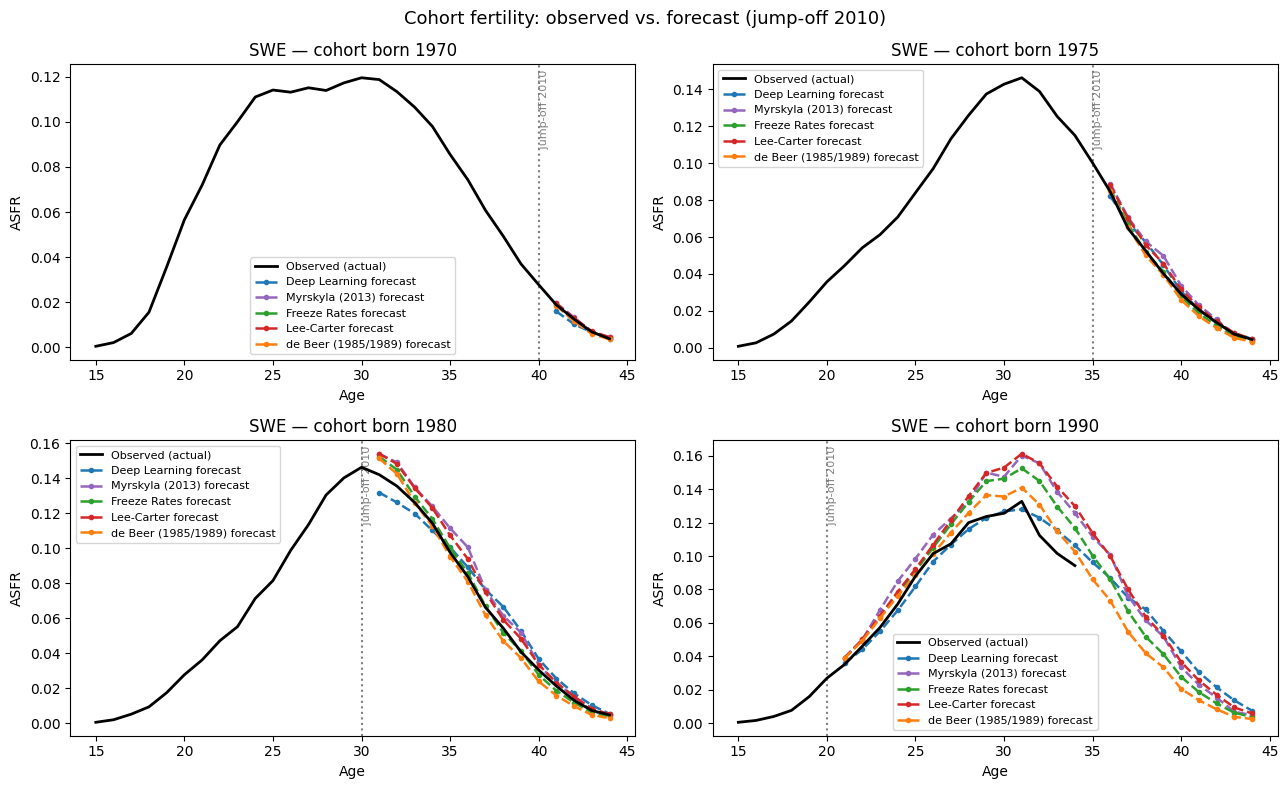

In [22]:
# ============================================================
# Observed vs. forecast cohort fertility trajectories
# ============================================================

# country index -> country code (for nicer titles)
_geos = np.load('../../data/geos_key.npy', allow_pickle=True)
GEO_NAMES = {int(idx): code for code, idx in _geos}
print(GEO_NAMES)

# Each method: label -> (observed_df, predicted_df, color)
METHODS = {
    'Deep Learning':   (df_obs_cohort_dl,  df_pred_cohort_dl,  '#1f77b4'),
    'Lee-Carter':      (df_obs_cohort_lee, df_pred_cohort_lee, '#d62728'),
    'Freeze Rates':    (df_obs_cohort_fr,  df_pred_cohort_fr,  '#2ca02c'),
    'Myrskyla (2013)': (df_obs_cohort_my,  df_pred_cohort_my,  '#9467bd'),
    'de Beer (1985/1989)': (df_obs_cohort_db,  df_pred_cohort_db,  '#ff7f0e'),
}


def plot_cohort_forecasts(country, jump_off_year, birth_years,
                          methods=('Deep Learning',)):
    """Trace observed vs. forecast ASFR over age for a selection of cohorts.

    One subplot per cohort (identified by birth `Year`). Observed rates are
    drawn as a solid black line across all ages; each method's forecast is a
    dashed colored line for the post-jump-off ages. A dotted vertical line
    marks the jump-off year, which for a cohort born in `by` sits at
    age = jump_off_year - by.
    """
    n = len(birth_years)
    ncols = min(2, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4 * nrows),
                             squeeze=False)
    axes = axes.ravel()

    for ax, by in zip(axes, birth_years):
        split_age = jump_off_year - by  # age at which the jump-off year falls

        # --- observed truth (same across methods) ---
        obs_df = METHODS[methods[0]][0]
        obs = obs_df[(obs_df['Country'] == country) &
                     (obs_df['JumpOffYear'] == jump_off_year) &
                     (obs_df['Year'] == by)].sort_values('Age')
        if not obs.empty:
            ax.plot(obs['Age'], obs['Rate'], '-', color='black', lw=2,
                    label='Observed (actual)', zorder=5)

        # --- each method's forecast, restricted to post-jump-off ages ---
        for label in methods:
            _, pred_df, color = METHODS[label]
            pred = pred_df[(pred_df['Country'] == country) &
                           (pred_df['JumpOffYear'] == jump_off_year) &
                           (pred_df['Year'] == by)].sort_values('Age')
            fc = pred[(pred['Year'] + pred['Age']) > jump_off_year]
            if not fc.empty:
                ax.plot(fc['Age'], fc['Rate'], '--', color=color, lw=1.8,
                        marker='o', markersize=3, label=f'{label} forecast')

        # --- jump-off marker ---
        if obs['Age'].min() <= split_age <= obs['Age'].max() if not obs.empty else True:
            ax.axvline(split_age, color='gray', ls=':', lw=1.5)
            ax.text(split_age, ax.get_ylim()[1] * 0.98,
                    f' jump-off {jump_off_year}', rotation=90,
                    va='top', ha='left', fontsize=8, color='gray')

        ax.set_title(f'{GEO_NAMES.get(country, country)} — cohort born {by}')
        ax.set_xlabel('Age')
        ax.set_ylabel('ASFR')
        ax.legend(fontsize=8)

    # hide any unused axes
    for ax in axes[len(birth_years):]:
        ax.set_visible(False)

    fig.suptitle(f'Cohort fertility: observed vs. forecast '
                 f'(jump-off {jump_off_year})', fontsize=13)
    plt.tight_layout()
    return fig


fig = plot_cohort_forecasts(
    country=35,                      
    jump_off_year=2010,
    birth_years=[1970, 1975, 1980, 1990],
    methods=('Deep Learning', 'Myrskyla (2013)', 'Freeze Rates', 'Lee-Carter', 'de Beer (1985/1989)'),
)
#fig.savefig('../../figures/cohort_forecast_trajectories_irl_1990.png', dpi=300,
       #     bbox_inches='tight')
plt.show()

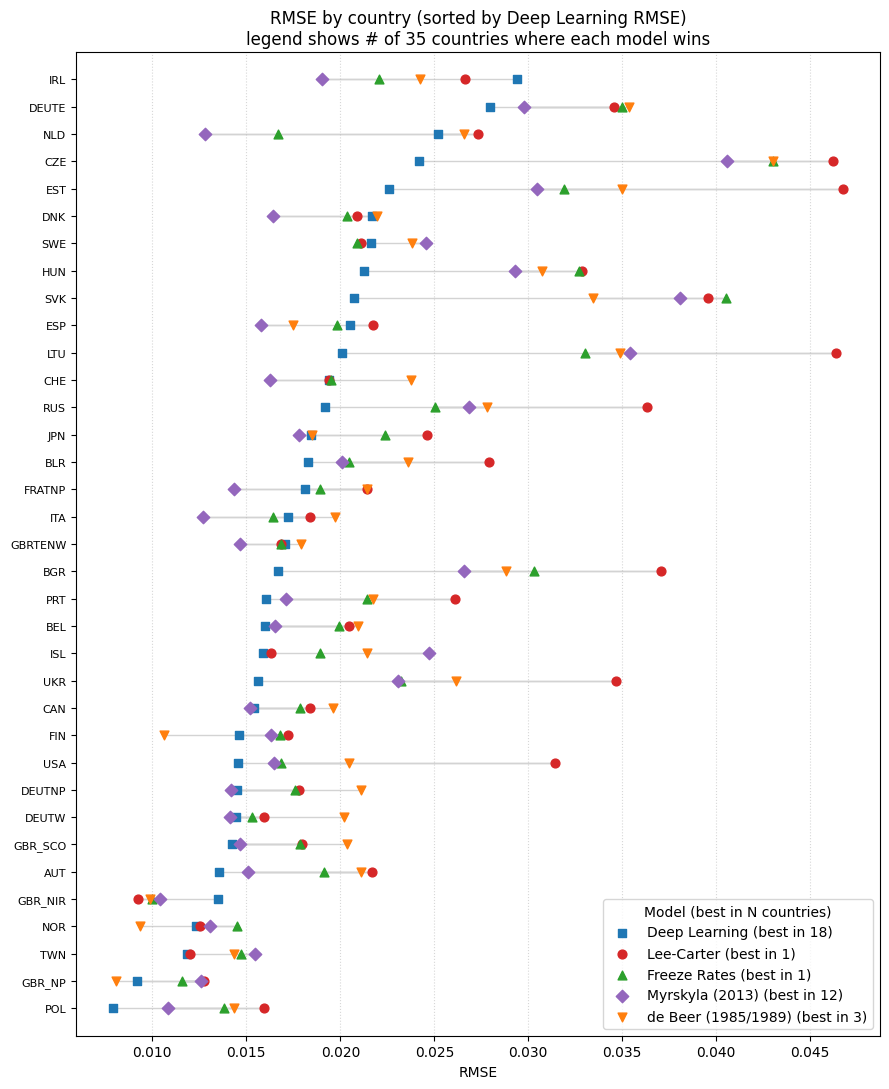

In [24]:
# ============================================================
# RMSE by country, all methods (dot plot, sorted by DL RMSE)
# ============================================================
# RMSE over a merged (pred vs obs) frame or groupby subset
def _rmse(d):
    return np.sqrt(np.mean((d['Rate_pred'] - d['Rate_obs']) ** 2))

# Merge each method's forecasts with its observed rates on the shared keys
merged_by_model = {
    name: pred_df.merge(
        obs_df[key_cols + ['Rate']], on=key_cols, how='inner',
        suffixes=('_pred', '_obs')
    )
    for name, (obs_df, pred_df, _) in METHODS.items()
}

rmse_country = pd.DataFrame({
    name: dfm.groupby('Country').apply(_rmse)
    for name, dfm in merged_by_model.items()
})

# for each country, which model has the lowest RMSE -> count wins per model
best_counts = rmse_country.idxmin(axis=1).value_counts()

# sort countries by Deep Learning RMSE for readability
rmse_country = rmse_country.sort_values('Deep Learning')
labels = [GEO_NAMES.get(int(c), str(c)) for c in rmse_country.index]
y = np.arange(len(rmse_country))

fig, ax = plt.subplots(figsize=(9, 11))
for name, (_, _, color) in METHODS.items():
    marker = dict(zip(METHODS, ['s', 'o', '^', 'D', 'v', 'P']))[name]
    legend_label = f'{name} (best in {best_counts.get(name, 0)})'
    ax.scatter(rmse_country[name], y, color=color, label=legend_label,
               marker=marker, s=40, zorder=3)

# faint connector so each country's spread is easy to read
for yi in y:
    ax.plot(rmse_country.iloc[yi].values, [yi] * rmse_country.shape[1],
            color='lightgray', lw=1, zorder=1)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_ylim(-1, len(y))
ax.set_xlabel('RMSE')
ax.set_title(f'RMSE by country (sorted by Deep Learning RMSE)\n'
             f'legend shows # of {len(rmse_country)} countries where each model wins')
ax.legend(title='Model (best in N countries)')
ax.grid(axis='x', ls=':', alpha=0.5)
plt.tight_layout()
plt.savefig('../../figures/rmse_by_country.png', dpi=300, bbox_inches='tight')
plt.show()